# Fitting more complex models to photometry with Bagpipes

In the previos example we covered some of the basics, now let's look at fitting a more complex model.

## Setting up

Once again we'll need to load up the observational data, we'll use the same object as last time.

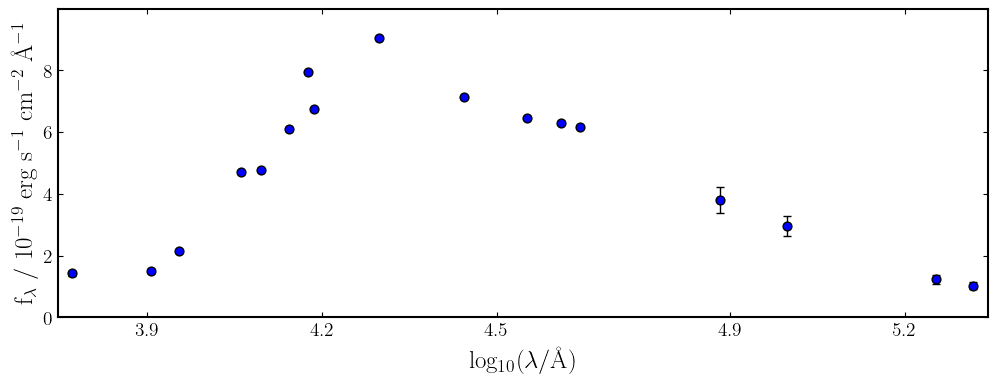

In [1]:
import numpy as np 
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

import bagpipes as pipes
import matplotlib.pyplot as plt
#%matplotlib inline

from astropy.io import fits
from astropy.table import Table

def load_bluejay(ID):
    """ Load BlueJay photometry from the BlueJay catalogue(s)"""

    # Blue Jay catalogue
    bluejay_cat = Table.read("bluejay_phot_cat_v1.4.fits")
    
    # 1. List all available HST/NIRCam bands:
    filters = ['F090W', 'F115W', 'F125W', 'F140W', 'F150W', 'F160W', 
               'F200W', 'F277W', 'F356W', 'F410M', 'F444W', 'F606W', 'F814W']
    
    # 2. Find the correct row using the ID column
    # Use a mask rather than (int(ID) - 1) to be safe against non-sequential IDs
    row = bluejay_cat[bluejay_cat['ID'] == int(ID)]

    if len(row) == 0:
        raise ValueError(f"ID {ID} not found in catalogue.")
    
    # 3. Extract fluxes and errors into lists
    fluxes = []
    flux_errs = []

    for f in filters:
        fluxes.append(row[f + "_flux"][0] * 1e6)
        flux_errs.append(row[f + "_flux_err"][0] * 1e6)


    # MIRI catalogue
    miri_cat = Table.read("Phot_Table_MIRI.fits")
    
    # 1. List all available MIRI bands:
    miri_filters = ['F770W', 'F1000W', 'F1800W', 'F2100W']
    
    # 2. Find the correct row using the ID column
    # Use a mask rather than (int(ID) - 1) to be safe against non-sequential IDs
    row = miri_cat[miri_cat['ID'] == int(ID)]

    if len(row) == 0:
        raise ValueError(f"ID {ID} not found in catalogue.")
    
    # 3. Extract fluxes and errors into lists
    for f in miri_filters:
        fluxes.append(row[f + "_flux"][0] * 1e6)
        flux_errs.append(row[f + "_flux_err"][0] * 1e6)
    
    # Now turn these into a 2D array [N_filters, 2]
    # Bagpipes expects photometry[i, 0] = flux, photometry[i, 1] = error
    photometry = np.c_[fluxes, flux_errs]
    
    # 5. Clean up missing data and enforce SNR limits
    for i in range(len(photometry)):
        # Blow up errors for missing data (NaN or 0 flux)
        if (photometry[i, 0] <= 0.) or (np.isnan(photometry[i, 0])):
            photometry[i, :] = [0., 9.9e99]
            continue # Skip SNR check for bad data
    
    return photometry

bluejay_filt_list = np.loadtxt("filters/bluejay_filt_list.txt", dtype="str")

galaxy = pipes.galaxy("12020", load_bluejay, spectrum_exists=False, filt_list=bluejay_filt_list)

fig = galaxy.plot()

# Replicating the Prospector Model

Specify all parameters such that they match the Prospector model that Letizia used for my galaxies.

Prospector Parameter    Bagpipes Equivalent     Translation Notes
zred                    redshift                "Use (1.764, 0.5) for a Gaussian."
logzsol                 metallicity             Convert log to linear (10−2 to 100.5).
logmass                 massformed              "Bagpipes uses total formed mass, not current stellar mass."
dust2                   Av                      AV​=1.086×optical depth.
dust_index              eta                     Bagpipes' cf00 model uses eta for the slope.

In [3]:
from astropy.cosmology import WMAP9 as cosmo

def get_zred(galaxy_id):    
    # --- Read Blue Jay catalogue ---
    blue = "/Users/benjamincollins/University/Master/BlueJay/BlueJay_sample.txt"
    tbl = Table.read(blue, format="ascii.basic")
    
    row = tbl[tbl['id'] == int(galaxy_id)]
    z_spec = row['z_spec'][0]
    return z_spec

zred = get_zred(12202)


def zred_to_agelims(zred=None, nbins_sfh=None):
    tuniv = cosmo.age(zred).value*1e9
    print(f"Age of the universe at z={zred:.2f} is {tuniv/1e9:.2f} Gyr")
    tbinmax = (tuniv*0.9)
    agelims = [0.0,7.4772] + np.linspace(8.0,np.log10(tbinmax),nbins_sfh-2).tolist() + [np.log10(tuniv)]
    agelims = 10**np.array(agelims)/1e6 # transform to Myr like Bagpipes expects
    agelims[0] = 0.0    # Make the bins start at 0 Gyr
    return agelims.tolist()


# 1. SFH: Mapping the 14-bin Continuity model
# Note: Bagpipes "piecewise" expects massformed in linear units for the prior 
# or log10 if specified. Here we use the TopHat bounds from the logmass prior.
continuity = {}
continuity["massformed"] = (8.5, 12.5) 
continuity["metallicity"] = (0, 2.5) # Linear Z/Z_solar: 0.01 to 3.16

# Defining the specific age bins in Gyr
nbins_sfh = 6
age_lims = zred_to_agelims(zred=zred, nbins_sfh=nbins_sfh)
print("Age limits (Gyr):", age_lims)
continuity["bin_edges"] = age_lims

# In Bagpipes, the 'continuity' model automatically applies 
# a Student's t prior to the ratios of the bins.
# However, we should define the 'slope' or 'sigma' of that prior:
for i in range(1, len(age_lims)-1):
    # This sets the 'width' of the Student's t distribution for each bin ratio
    # To match Prospector's 'scale=0.3', we set the prior here:
    continuity[f"dsfr{i}"] = (-3.0, 3.0)

print(continuity)
    
exp = {}                                  # Tau-model star-formation history component
exp["age"] = (0.1, 15.)                   # Vary age between 100 Myr and 15 Gyr. In practice 
                                          # the code automatically limits this to the age of
                                          # the Universe at the observed redshift.

exp["tau"] = (0.3, 10.)                   # Vary tau between 300 Myr and 10 Gyr
exp["massformed"] = (1., 15.)             # vary log_10(M*/M_solar) between 1 and 15
exp["metallicity"] = (0., 2.5)            # vary Z between 0 and 2.5 Z_oldsolar

dblplaw = {}                        
dblplaw["tau"] = (0., 15.)                # Vary the time of peak star-formation between
                                          # the Big Bang at 0 Gyr and 15 Gyr later. In 
                                          # practice the code automatically stops this
                                          # exceeding the age of the universe at the 
                                          # observed redshift.
            
dblplaw["alpha"] = (0.01, 1000.)          # Vary the falling power law slope from 0.01 to 1000.
dblplaw["beta"] = (0.01, 1000.)           # Vary the rising power law slope from 0.01 to 1000.
dblplaw["alpha_prior"] = "log_10"         # Impose a prior which is uniform in log_10 of the 
dblplaw["beta_prior"] = "log_10"          # parameter between the limits which have been set 
                                          # above as in Carnall et al. (2017).
dblplaw["massformed"] = (1., 15.)
dblplaw["metallicity"] = (0., 2.5)


# 2. Dust: Mapping cf00 (Charlot & Fall)
# Prospector dust2 prior was TopHat(0, 4.0) optical depth
# Conversion: Av = 1.086 * tau = 4.344
dust = {}
dust["type"] = "CF00"

dust["Av"] = (0., 3.)          # This is the culprit!!

dust["eta"] = 1.0         # Corresponds to my dust_index/slope
dust["n"] = 0.7                 # Fixed slope at the standard CF00 value
#dust["t_bc"] = 0.01

#dust = {}                           
#dust["type"] = "Calzetti"
#dust["Av"] = (0., 2.)

# 3. Nebular: Mapping gas_logu and gas_logz
nebular = {}
nebular["logU"] = -3.

fit_instructions = {}

fit_instructions["redshift"] = (zred-0.1, zred+0.1)       # Uniform redshift prior
fit_instructions["redshift_prior"] = "Gaussian"           # Additional Gaussian prior centred on the spectroscopic redshift
fit_instructions["redshift_prior_mu"] = zred
fit_instructions["redshift_prior_sigma"] = 0.005

fit_instructions["t_bc"] = 0.01

#fit_instructions["dblplaw"] = dblplaw 
#fit_instructions["exponential"] = exp
fit_instructions["continuity"] = continuity
fit_instructions["dust"] = dust
fit_instructions["nebular"] = nebular



Age of the universe at z=2.63 is 2.51 Gyr
Age limits (Gyr): [0.0, 30.005440024430936, 100.0, 282.86416811350347, 800.1213760254435, 2263.256674192688, 2514.7296379918735]
{'massformed': (8.5, 12.5), 'metallicity': (0, 2.5), 'bin_edges': [0.0, 30.005440024430936, 100.0, 282.86416811350347, 800.1213760254435, 2263.256674192688, 2514.7296379918735], 'dsfr1': (-3.0, 3.0), 'dsfr2': (-3.0, 3.0), 'dsfr3': (-3.0, 3.0), 'dsfr4': (-3.0, 3.0), 'dsfr5': (-3.0, 3.0)}


## Making a more interesting model

Instead of an ordinary tau model let's try fitting a double-power-law star-formation history, we'll also include nebular emission this time. This is also a good time to think about the priors we're imposing on our fitting parameters. By default Bagpipes will fit a uniform prior between the limits you set, but you can change that as follows:

In [135]:
dblplaw = {}                        
dblplaw["tau"] = (0., 15.)                # Vary the time of peak star-formation between
                                          # the Big Bang at 0 Gyr and 15 Gyr later. In 
                                          # practice the code automatically stops this
                                          # exceeding the age of the universe at the 
                                          # observed redshift.
            
dblplaw["alpha"] = (0.01, 1000.)          # Vary the falling power law slope from 0.01 to 1000.
dblplaw["beta"] = (0.01, 1000.)           # Vary the rising power law slope from 0.01 to 1000.
dblplaw["alpha_prior"] = "log_10"         # Impose a prior which is uniform in log_10 of the 
dblplaw["beta_prior"] = "log_10"          # parameter between the limits which have been set 
                                          # above as in Carnall et al. (2017).
dblplaw["massformed"] = (1., 15.)
dblplaw["metallicity"] = (0., 2.5)

dust = {}                           
dust["type"] = "Calzetti"
dust["Av"] = (0., 2.)

nebular = {}
nebular["logU"] = -3.

fit_info = {}                            # The fit instructions dictionary
fit_info["redshift"] = (0., 10.)         # Vary observed redshift from 0 to 10

fit_info["redshift_prior"] = "Gaussian"  # From looking at the spectrum in Example 2 it's
fit_info["redshift_prior_mu"] = 1.0      # clear that this  object is at around z = 1. We'll 
fit_info["redshift_prior_sigma"] = 0.25  # include that information with a broad Gaussian
                                         # prior centred on redshift 1. Parameters of priors
                                         # are passed starting with "parameter_prior_".
fit_info["dblplaw"] = dblplaw 
fit_info["dust"] = dust
fit_info["nebular"] = nebular

# Fitting the same object multiple times with different runs

Now we're ready to fit the object, but there's a problem, the posterior distribution for the previous example is still there. We can fit a fresh model without deleting our previous outputs by setting the run keyword argument of the fit object, which causes the output posterior to be saved under "pipes/posterior/run" instead "pipes/posterior" and the same for output plots.

In [ ]:
fit = pipes.fit(galaxy, fit_instructions)

fit.fit(verbose=True, sampler='nautilus', n_live=1000, pool=5)

fig = fit.plot_spectrum_posterior(save=False, show=True)
fig = fit.plot_sfh_posterior(save=False, show=True)
fig = fit.plot_corner(save=False, show=True)


Bagpipes: fitting object 12020

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    


Process SpawnPoolWorker-120:
Process SpawnPoolWorker-123:
Process SpawnPoolWorker-124:
Process SpawnPoolWorker-121:
Process SpawnPoolWorker-122:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/bagpipes/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/bagpipes/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/bagpipes/lib/python3.11/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
                    ^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/bagpipes/lib/python3.11/multiprocessing/pool.py", line 48, in mapstar
    return list(map(*args))
           ^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/nautilus/pool.py", line 33, in likelihood_worker
    return LIKELIHOOD(*args)
           ^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/bagpipes/lib/python3.1

KeyboardInterrupt: 

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.


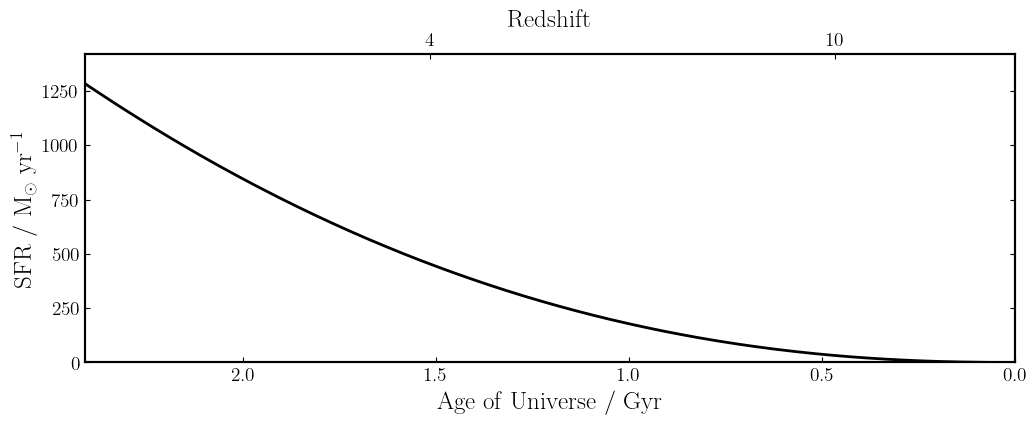

In [144]:
fig, ax = fit.plot_sfh_posterior(save=False, show=True)

In [140]:
list(fit.posterior.samples)

['dblplaw:alpha',
 'dblplaw:beta',
 'dblplaw:massformed',
 'dblplaw:metallicity',
 'dblplaw:tau',
 'dust:Av',
 'redshift',
 'stellar_mass',
 'formed_mass',
 'sfr',
 'ssfr',
 'nsfr',
 'mass_weighted_age',
 'tform',
 'tquench',
 'mass_weighted_zmet',
 'sfh',
 'photometry',
 'spectrum_full',
 'uvj',
 'chisq_phot',
 'dust_curve']

In [143]:
fit.posterior.samples["sfr"]

array([1219.05067774, 1218.88686058, 1222.60927163, 1223.72804113,
       1233.15225624, 1231.15412552, 1225.42572752, 1230.84121588,
       1229.66257765, 1221.541896  , 1224.47466859, 1223.70504794,
       1225.38352244, 1229.6469369 , 1235.17815938, 1225.12669125,
       1218.78622044, 1225.68221626, 1224.22662255, 1218.72796956,
       1227.01459629, 1224.71964297, 1228.29467673, 1231.20615124,
       1225.53984855, 1229.93455079, 1216.56463725, 1227.26322963,
       1229.38187318, 1224.69615515, 1231.45174142, 1220.99296906,
       1222.19568294, 1218.50451523, 1223.67470032, 1218.57715282,
       1226.04739382, 1222.96960647, 1232.61301126, 1231.98475337,
       1223.5943158 , 1218.49233756, 1225.82169378, 1222.75411065,
       1231.27143223, 1217.22463062, 1225.72378199, 1222.32718732,
       1225.46739964, 1225.17527509, 1230.72917907, 1221.05222548,
       1223.89459337, 1230.63886814, 1221.15648614, 1225.69421144,
       1229.16885072, 1218.54475774, 1228.83594403, 1225.39464

That's about it for fitting photometry, go on to the next example to learn about fitting spectroscopy.

# Let's generate a super simple model for bagpipes to fit so that I can figure out how to do the nonparametric starformation histories

In [ ]:

# Let's start with a simple constant SFH, which is a special 
# case of the double power law with alpha=beta=0.

constant = {}                               # Tophat function
constant["massformed"] = (8.5, 12.5)        # Log10 of solar mass formed
constant["metallicity"] = (0.01, 2.5)       # Linear Z/Z_solar: 0.01 to 3.16
constant["age_max"] = 2.3                   # Time since SF switched on: Gyr
constant["age_min"] = 0.5                   # Time since SF switched off: Gyr

# Nebular component
nebular = {}
nebular["logU"] = -3.                       # Log_10 of the ionization parameter.
nebular["fesc"] = 0.1                       # IMPORTANT: Escape fraction of ionising photons.

# Dust absorption parameters
dust = {}                                 # Dust component
dust["type"] = "Calzetti"                 # Define the shape of the attenuation curve
dust["Av"] = (0., 2.)                     # Vary Av between 0 and 2 magnitudes

# Dust emission parameters (now free parameters)
dust["qpah"] = (0.1, 4.58)                     # PAH mass fraction
dust["umin"] = (0.1, 25.)                    # Lower limit of starlight intensity distribution
dust["gamma"] = (0., 1.0)                    # Fraction of stars at umin


fit_instructions = {}                               # The fit instructions dictionary
fit_instructions["redshift"] = (zred-1, zred+1)     # Set the redshift prior to vary within +/1 of the spectroscopic redshift
fit_instructions["redshift_prior"] = "Gaussian"     # Use a Gaussian prior
fit_instructions["redshift_prior_mu"] = zred        # Centred on the spectroscopic redshift
fit_instructions["redshift_prior_sigma"] = 0.005    # With a very narrow width

fit_instructions["constant"] = constant   
fit_instructions["dust"] = dust

print(fit_instructions)

{'redshift': (np.float64(1.63), np.float64(3.63)), 'redshift_prior': 'Gaussian', 'redshift_prior_mu': np.float64(2.63), 'redshift_prior_sigma': 0.005, 'constant': {'massformed': (8.5, 12.5), 'metallicity': (0.01, 2.5), 'age_max': 2.3, 'age_min': 0.5}, 'dust': {'type': 'Calzetti', 'Av': (0.0, 2.0), 'qpah': (0.1, 4.58), 'umin': (0.1, 25.0), 'gamma': (0.0, 1.0)}}


Now run the galaxy with minimal parameters


Bagpipes: fitting object 12020

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 78     | 1        | 4        | 46900    | N/A    | 1780  | -4936.38 

Completed in 100.4 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
constant:massformed           11.719     11.720     11.721
constant:metallicity           2.473      2.486      2.495
dust:Av                        0.188      0.192      0.198
dust:gamma                     0.246      0.532      0.802
dust:qpah         

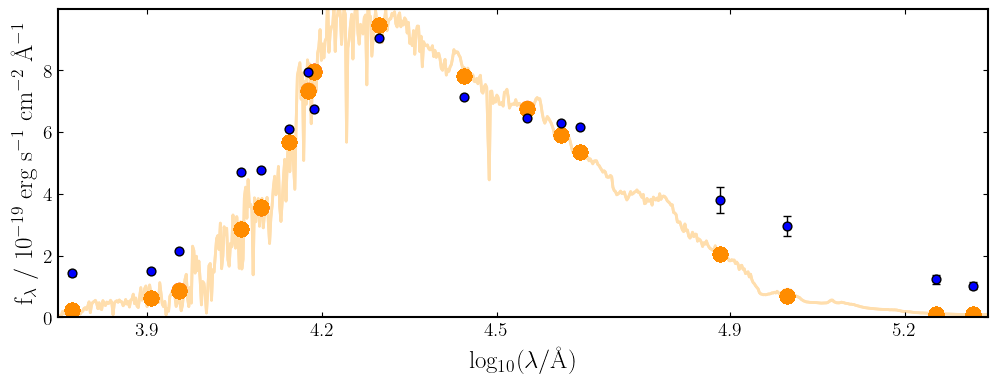

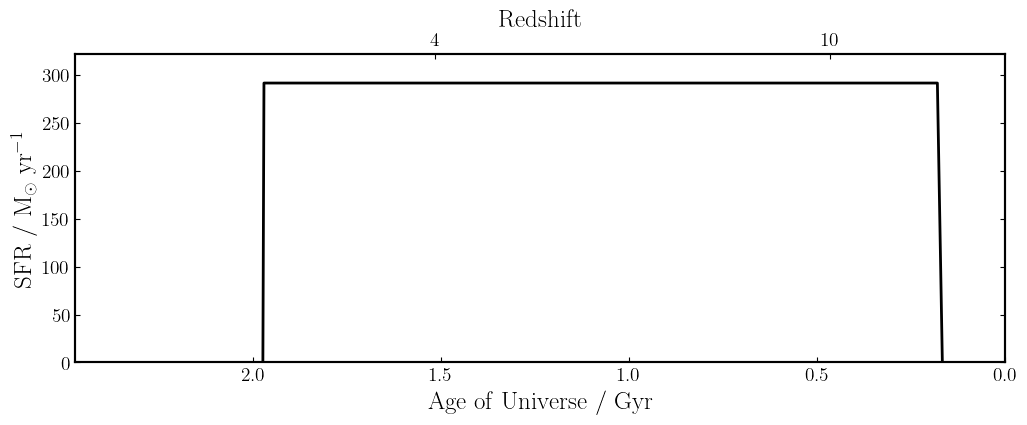

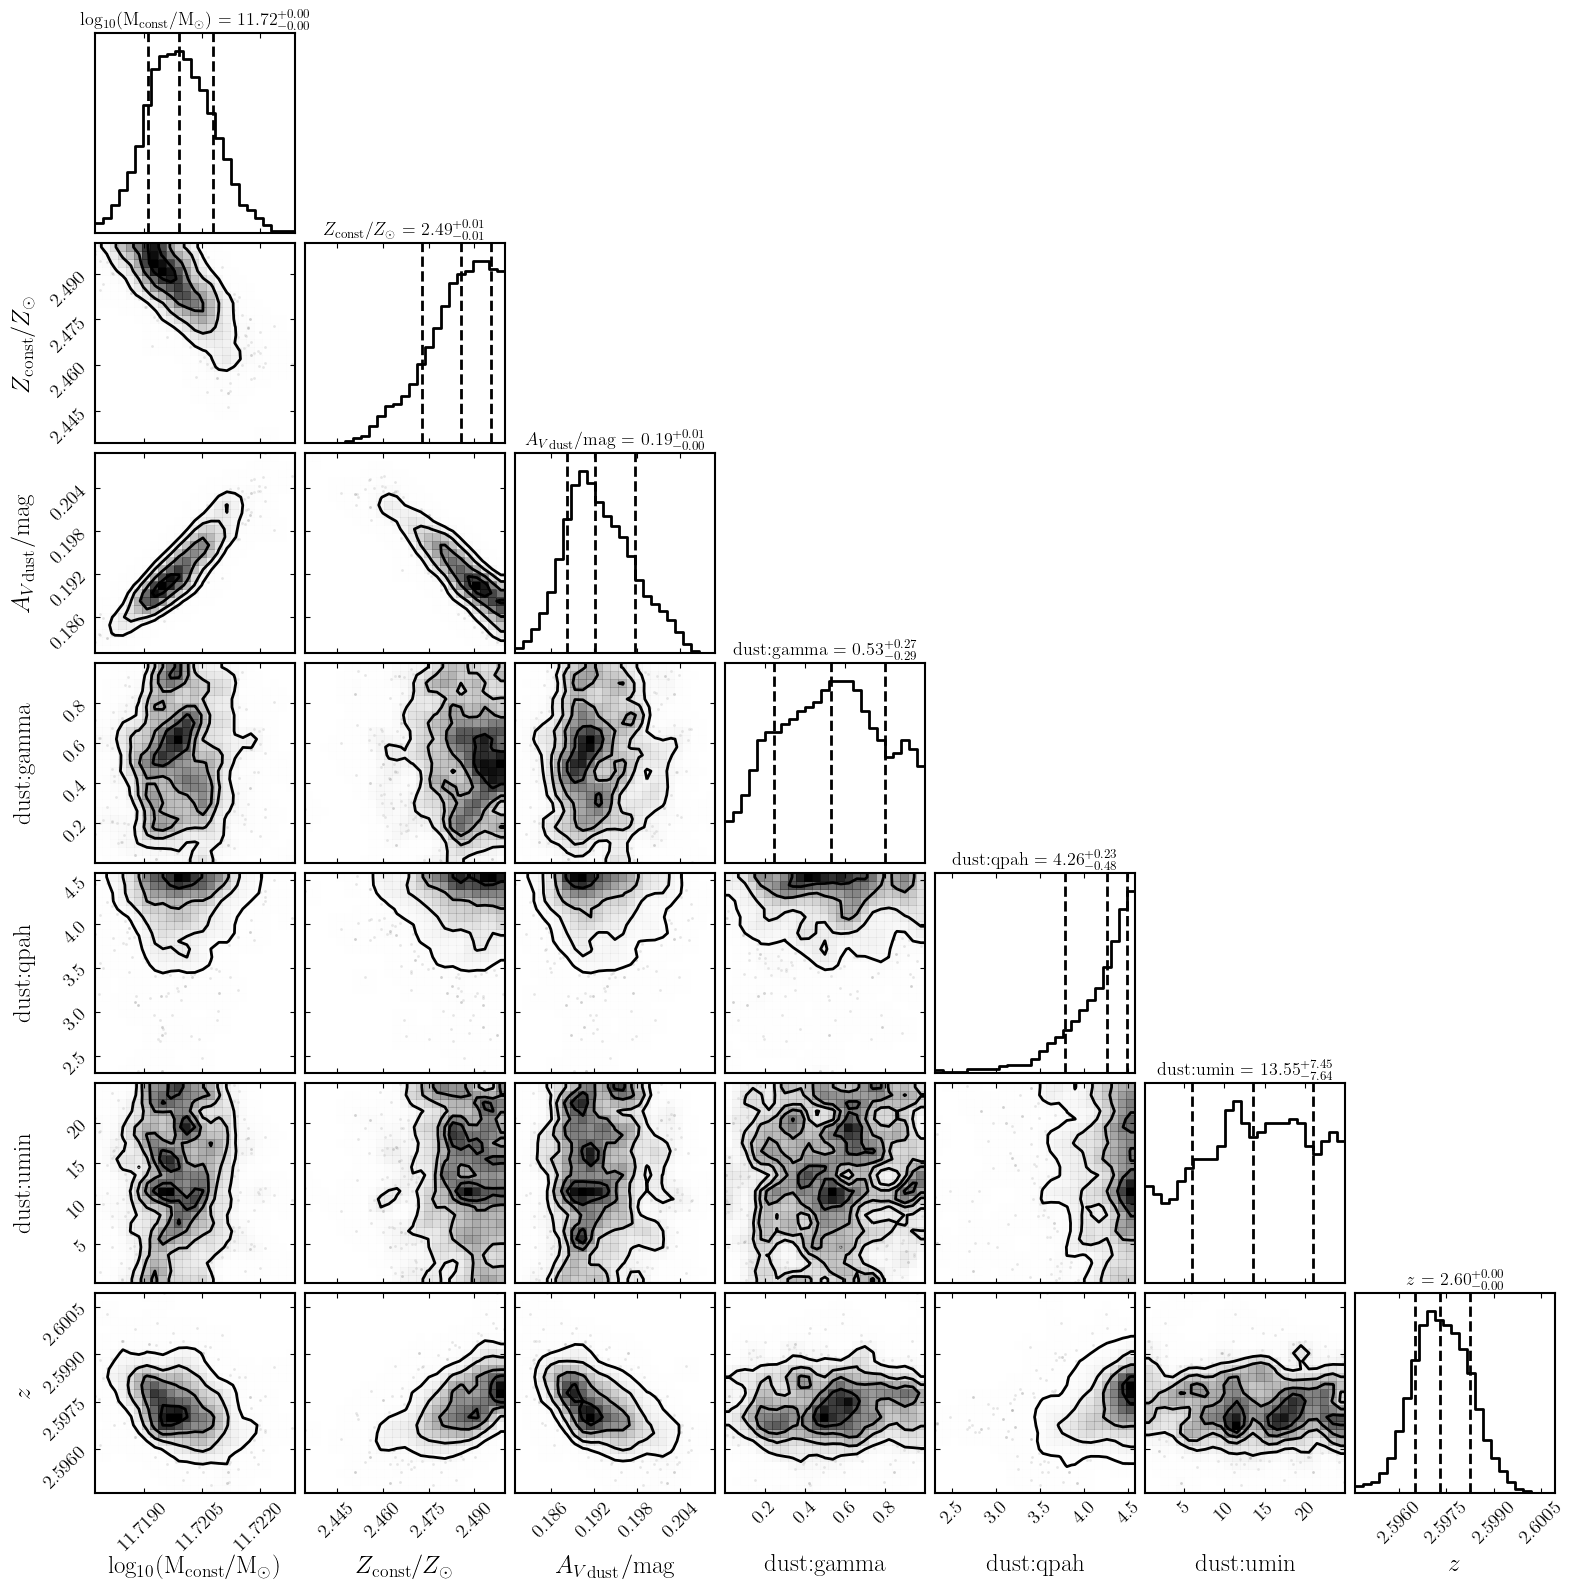

In [16]:
fit = pipes.fit(galaxy, fit_instructions, run="fesc")

fit.fit(verbose=True, sampler='nautilus', discard_exploration=True, pool=4)

fig = fit.plot_spectrum_posterior(save=False, show=True)
fig = fit.plot_sfh_posterior(save=False, show=True)
fig = fit.plot_corner(save=False, show=True)

In [10]:
import bagpipes as pipes
from bagpipes import config
print("qpah grid:", config.qpah_vals)
print("umin grid:", config.umin_vals)

qpah grid: [0.1  0.47 0.75 1.12 1.49 1.77 2.37 2.5  3.19 3.9  4.58]
umin grid: [ 0.1   0.15  0.2   0.3   0.4   0.5   0.7   0.8   1.    1.2   1.5   2.
  2.5   3.    4.    5.    7.    8.   10.   12.   15.   20.   25.  ]
